# Фильм на века

Наш заказчик - режиссер, мечтающий завоевать народную любовь и остаться если не в века в топе рейтинга самых высоко оцененных фильмов.

Наша цель - собрать для него датасет популярных фильмов с Letterboxd и провести исследование, какие характеристики фильма (жанр, страна производства, язык, период выпуска, наличие «Оскара») чаще встречаются у фильмов с более высоким рейтингом.

Сразу ответим, что мы будем искать связи и корреляции, а не причинно-следственные зависимости, чтобы лучше понять структуру популярных фильмов.

План работы:
1. Парсинг списка популярных фильмов https://letterboxd.com/films/popular/ и сбор деталей по каждому фильму: название, год, рейтинг, режиссера, страну, язык, жанры, студию.
2. Очистка данных: пропуски, дубликаты, приведение типов.
3. Создание новых признаков: временные признаки, языковые признаки, производство, получение наград.
4. Разведывательный анализ: сравнение средних, группировки, корреляции.
5. Визуализация ключевых результатов и формулировка выводов.

Проверяемые описателньгипотезы:
- Фильмы с «Оскаром» в среднем имеют более высокий рейтинг.
- Производство с участием USA чаще встречается среди высокорейтинговых фильмов.
- Фильмы только на английском отличаются по рейтингу от фильмов с несколькими языками.
- Международные проекты (несколько стран) отличаются по рейтингу.
- Жанры и период выпуска связаны с рейтингом.

## Описание данных

Исходный датафрейм **df_main**

*   film - наименование фильма
*   year - год создания
*   url - ссылка на фильм на сайте letterboxd.com
*   rating - рейтинг






Исходный датафрейм **details**

*  film - наименование фильма
*  url - ссылка на фильм на сайте letterboxd.com
*  actors - список актёров
*  director - режиссёр фильма
*  country - страна
*  language - языки оригинала
*  studio - студия, на которой снимался фильм
*  genre - жанр фильм

Справочник фильмов с наградами оскар **dict_oscar**
*   oscar



Итоговый датафрейм **full_film_merged**

*   film - наименование фильма
*   year - год создания
*   url - ссылка на фильм на сайте letterboxd.com
*   rating - рейтинг
*   actors - список актёров
*   director - режиссёр фильма
*   country - страна
*   language - языки оригинала
*   studio - студия, на которой снимался фильм
*   genre - жанр фильм
*   has_oscar- признак имеет ли фильм награду Оскар(да,нет)
*   decade- десятилетия (например с 2020-2010)
*   decade_start - начало десятилетия
*   century - век
*   movie fees - кассовые сборы фильма
*   movie fees with commas  - кассовые сборы фильма с разбиением
*   hollywood - признак фильма, снятого в Голливуде
*   international - признак участия в фильме нескольких стран
*   english_only - фильм на английском языке
*   n_languages - количество языков в фильме
*   five_year - пятилетия (например 2000,2005)
*   genres_split - жанр фильм разделённый по запятым в виде словаря


# Импорт библиотек

In [3]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from bs4 import BeautifulSoup
import time
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# Парсинг

## Этап 1. Предобработка данных

Выбираем, сколько фильмов парсить:

In [ ]:
N = 2100

In [ ]:
br = webdriver.Chrome()
br.get('https://letterboxd.com/films/popular/')
time.sleep(3)

Формируем основной датасет, который задаст нам направление для начала работы:
* создаем словари, в которые будем записывать скачанные данные;
* находим нужные компоненты и классы в исходном коде;
* через кнопку "next" осуществляем парсинг данных с сайта.

In [ ]:
films = []
urls = []
ratings = []

while len(films) < N:
    br.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(1)

    soup = BeautifulSoup(br.page_source, 'html.parser')
    film_containers = soup.find_all('li', class_='posteritem')

    for container in film_containers:
        if len(films) > N:
            break

        react_component = container.find('div', class_='react-component')

        if react_component:
            film_name = react_component.get('data-item-name')
            film_url = react_component.get('data-item-link')

            if film_name and film_url:
                film_link = f'https://letterboxd.com{film_url}'
                film_rating = container.get('data-average-rating', 'N/A')

                films.append(film_name)
                urls.append(film_link)
                ratings.append(film_rating)

    next_buttons = br.find_elements(By.CSS_SELECTOR, 'a.next')
    if next_buttons and next_buttons[0].is_enabled():
        next_buttons[0].click()
        time.sleep(3)
    else:
        break

br.quit()

Обрабатываем годы с помощью регулярных выражений, так как фильмы парсятся в формате "название_фильма (год)":

In [ ]:
films_names = []
years = []
for film in films:
    film_str = str(film)
    year_match = re.search(r'\((\d{4})\)$', film_str)

    if year_match:
        year = year_match.group(1)
        name = film_str[:film_str.rfind('(')].strip()
        years.append(year)
        films_names.append(name)
    else:
        years.append('N/A')
        films_names.append(film_str)

Формируем наш основной датафрейм:

In [ ]:
df_main = pd.DataFrame({
    "film": films_names,
    "year": years,
    "url": urls,
    "rating": ratings
})

И сохраняем его:

In [ ]:
df_main.to_csv("main.csv", index=False, encoding='utf-8')

Собираем детали по каждому фильму:
* создаем список, в котором будем сохранять информацию об актерах, режиссерах, студиях, странах, жанрах и языках;
* обращаемся к каждому сохраненному url с фильмом, что у нас имеется;
* создаем пустой словарь и записываем туда название фильмов и url из соответствующих списков;
* для получения информации о странах, языках и студии переходим на новую ссылку, путем склеивания исходной ссылки с фильмом и раздела "details";
* для получения информации о жанрах переходим на новую ссылку, путем склеивания исходной ссылки с фильмом и раздела genres;
* добавляем записанные данные в словаре в наш исходный список, тем самым формируя наш датасет.

In [ ]:
br = webdriver.Chrome()
time.sleep(2)

rows = []

for i, url in enumerate (urls[:N]):
    row = {}
    row["film"] = films_names[i]
    row["url"] = urls[i]

    br.get(url)
    time.sleep(3)

    actor_elements = br.find_elements(By.CSS_SELECTOR, "a.text-slug.tooltip")
    if actor_elements:
        row["actors"] = [element.text.strip() for element in actor_elements[:8] if element.text.strip()]

    director_elements = br.find_elements(By.CSS_SELECTOR, "span.prettify")
    row["director"] = [element.text.strip() for element in director_elements if element.text.strip()]

    if url.endswith('/'):
        new_url = url + 'details/'
    else:
        new_url = url + '/details/'
    br.get(new_url)

    country_elements = br.find_elements(By.CSS_SELECTOR, ".text-sluglist a[href*='/country/']")
    language_elements = br.find_elements(By.CSS_SELECTOR, ".text-sluglist a[href*='/language/']")
    studio_elements = br.find_elements(By.CSS_SELECTOR, ".text-sluglist a[href*='/studio/']")

    row["country"] = [element.text.strip() for element in country_elements if element.text.strip()]
    row["language"] = [element.text.strip() for element in language_elements if element.text.strip()]
    row["studio"] = [element.text.strip() for element in studio_elements if element.text.strip()]

    if url.endswith('/'):
        genre_url = url + 'genres/'
    else:
        genre_url = url + '/genres/'
    br.get(genre_url)

    genre_elements = br.find_elements(By.CSS_SELECTOR, ".text-sluglist a[href*='/genre/']")
    row["genre"] = [element.text.strip() for element in genre_elements if element.text.strip()]

    rows.append(row)

br.quit()

Создаем датафрейм с полной информацией по фильмам:

In [ ]:
df_details = pd.DataFrame(rows)
df_details.head(3)

,film,url,actors,director,country,language,studio,genre
0,Parasite,https://letterboxd.com/film/parasite-2019/,"[Song Kang-ho, Lee Sun-kyun, Cho Yeo-jeong, Ch...","[Parasite, Bong Joon Ho]",[South Korea],"[Korean, English, German, Korean]",[Barunson E&A],"[Thriller, Comedy, Drama]"
1,Interstellar,https://letterboxd.com/film/interstellar/,"[Matthew McConaughey, Anne Hathaway, Michael C...","[Interstellar, Christopher Nolan]","[UK, USA]",[English],"[Legendary Pictures, Syncopy, Lynda Obst Produ...","[Science Fiction, Drama, Adventure]"
2,Barbie,https://letterboxd.com/film/barbie/,"[Margot Robbie, Ryan Gosling, America Ferrera,...","[Barbie, Greta Gerwig]","[UK, USA]",[English],"[LuckyChap Entertainment, Heyday Films, NB/GG ...","[Comedy, Adventure]"


Проверяем, что в наши данные с режиссерами не попали названия фильмов и при необходимости убираем их:

In [ ]:
df_details['director'] = df_details.apply(
    lambda x: x["director"][1:] if isinstance(x['director'], list) and len(x['director']) > 0 and x['director'][0] == x['film']
                                else x['director'],
    axis=1
)

Преобразуем списки в строки для корректного отображения данных в нашем датафрейме:

In [ ]:
columns_to_text_transform = ['actors', 'director', 'country', 'language', 'studio', 'genre']
for i in columns_to_text_transform:
    df_details[i] = df_details[i].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)

In [ ]:
df_details.to_csv('details.csv', index=False, encoding='utf-8')

### Парсер для фильмов, получивших оскар

В качестве основы для оскаров взяли сайт rottentomatoes.com и собрали оттуда фильмы, которые когда-либо побеждали в номинации "Лучший фильм"

In [ ]:
br = webdriver.Chrome()
br.get('https://editorial.rottentomatoes.com/guide/oscars-best-and-worst-best-pictures/')

films = []

fields = br.find_elements(By.CSS_SELECTOR, 'a[href*="/m/"]')

for field in fields:
    film_name = field.text.strip()
    if film_name and film_name not in ['[More]', '...'] and len(film_name) > 2:
        films.append(film_name)

df_oscar['film'] = df['film'].str.title()

In [ ]:
df_oscar = pd.DataFrame({'film': films})
df_oscar.to_csv('oscars.csv', index=False, encoding='utf-8')

**Промежуточные результаты:**

Мы собрали датасет популярных фильмов с сайта Letterbox. Парсинг был постраничный, с переходам на страницы каждого фильма.

В результате парсинга собрано более 2000 фильмов, для каждого фильма созданы признаки название, год, рейтинг, актёры, режиссёр, страна производства, языки, жанры, студия.

Дополнительно мы создали справочник фильмов-лауреатов премии «Оскар» для создания нового бинарного признака в исходной таблице.

# Этап 2. Сборка итогового датафрейма и очистка данных

Просмотрим все наши датасеты и проверим данные, которые в них хранятся

In [186]:
film = pd.read_csv("main.csv", encoding='utf-8')
details = pd.read_csv("details.csv", encoding='utf-8')
dict_oscar = pd.read_csv('oscars.csv', encoding='utf-8', sep='\t')

In [187]:
print(film.shape[0])
print(details.shape[0])
print(dict_oscar.shape[0])

2101
2100
98


In [188]:
film.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2101 entries, 0 to 2100
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   film    2101 non-null   object 
 1   year    2101 non-null   int64  
 2   url     2101 non-null   object 
 3   rating  2101 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 65.8+ KB


In [189]:
details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   film      2100 non-null   object
 1   url       2100 non-null   object
 2   actors    2099 non-null   object
 3   director  2100 non-null   object
 4   country   1969 non-null   object
 5   language  2100 non-null   object
 6   studio    2100 non-null   object
 7   genre     2099 non-null   object
dtypes: object(8)
memory usage: 131.4+ KB


In [190]:
print(film.columns)
print(details.columns)
print(dict_oscar.columns)

Index(['film', 'year', 'url', 'rating'], dtype='object')
Index(['film', 'url', 'actors', 'director', 'country', 'language', 'studio',
       'genre'],
      dtype='object')
Index(['film'], dtype='object')


Объединим все датафреймы в один общий, с которым в дальнейшем будем работать. В качестве ключа мы выбрали данные с ссылкой на фильмы:

In [191]:
full_film = pd.merge(
    film,
    details,
    on='url',
    how='left'
)

In [192]:
full_film.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2101 entries, 0 to 2100
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   film_x    2101 non-null   object 
 1   year      2101 non-null   int64  
 2   url       2101 non-null   object 
 3   rating    2101 non-null   float64
 4   film_y    2100 non-null   object 
 5   actors    2099 non-null   object 
 6   director  2100 non-null   object 
 7   country   1969 non-null   object 
 8   language  2100 non-null   object 
 9   studio    2100 non-null   object 
 10  genre     2099 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 180.7+ KB


In [193]:
full_film = full_film.rename(columns={'film_x': 'film'})
full_film = full_film.drop(columns='film_y')

full_film.columns

Index(['film', 'year', 'url', 'rating', 'actors', 'director', 'country',
       'language', 'studio', 'genre'],
      dtype='object')

Очистим датафрейм от дубликатов:

In [194]:
full_film = full_film.drop_duplicates(subset=['url'], keep='first')

In [195]:
dict_oscar = dict_oscar.rename(columns={'film': 'oscar'})

Объединим датафрейм с фильмами с датафреймом с оскарами:
* временно приведем названия фильмов в обоих датафреймах к нижнему регистру, чтобы корректно обработать данные;
* создадим новый бинарный признак для проверки наличия оскара у фильма;
* удалим исходную колонку с оскарами.

In [196]:
full_film_merged = pd.merge(
        full_film.assign(id_lower=full_film['film'].str.lower()),
        dict_oscar.assign(id_lower=dict_oscar['oscar'].str.lower()),
        on='id_lower',
        how='left'
    ).drop(columns=['id_lower'])

full_film_merged['has_oscar'] = full_film_merged['oscar'].notna().astype(int)
full_film_merged = full_film_merged.drop(columns=['oscar'])

Очистим данные. Для начала найдем пропуски и заполним их в каждом столбце:

In [197]:
full_film_merged.isna().sum()

film           0
year           0
url            0
rating         0
actors         2
director       1
country      132
language       1
studio         1
genre          2
has_oscar      0
dtype: int64

In [198]:
#посмотрим кол-во уникальных значений
categories = ["actors", "director", "country", "language", "genre", "studio"]
for i in categories:
    print(f"{i}: {full_film_merged[i].nunique()} уникальных значений")

actors: 2097 уникальных значений
director: 1092 уникальных значений
country: 239 уникальных значений
language: 422 уникальных значений
genre: 812 уникальных значений
studio: 1818 уникальных значений


In [199]:
#приводим к строке, убираем пробелы, заменяем пустые строки и кавычки на NaN:
for category in categories:
    mask_empty = full_film_merged[category].astype(str).str.strip() == ""
    full_film_merged.loc[mask_empty, category] = np.nan
full_film_merged.isna().sum()

#удаляем строки с NaN в year или rating, потому что мы не сможем ими воспользоваться для графиков, и у нас поедет статистика:
full_film_merged = full_film_merged.dropna(subset=["year", "rating"])

#удаляем строки с NaN в film, по той же причине: если фильм без режиссера, но с рейтингом ещё можно анализировать, то фильм без названия даже рассматривать не имеет смысла, ведь это как ID для всей строки, и у нас поедет статистика:
full_film_merged = full_film_merged.dropna(subset=["film"])

#остальные NaN в категориальных сделаем "Unknown", если что, удалим уже позже на графиках:
for category in categories:
    full_film_merged[category] = full_film_merged[category].fillna("Unknown")

Финальная проверка:

In [200]:
full_film_merged.isna().sum()

film         0
year         0
url          0
rating       0
actors       0
director     0
country      0
language     0
studio       0
genre        0
has_oscar    0
dtype: int64

**Промежуточные результаты:**

Мы проанализировали структуру и состав собранных данных, нашли пропуски в ряде столбцов.

Далее мы обработали данные:
- объединили несколько датасетов в единый датафрейм;
- удалили дубликаты по уникальному идентификатору (URL фильма);
- привели списковые значения к строковому формату для дальнейшего анализа;
- создали бинарный признак наличие «Оскара» по информациииз другого датафрейма.

Пропуски в категориальных признаках было решено оставить без заполнения,
так как их заполнение средними или модальными значениями могло бы исказить реальные данные.

Так, мы получили очищенный и структурированный датасет для создания новых признаков и дальнейшего анализа.


# Этап 3. Добавление новых атрибутов

Для проверки поставленных гипотез нам потребуется добавить несколько новых атрибутов

Для начала добавим данные о периодах фильмов в виде декад:

In [201]:
full_film_merged['five_year'] = (full_film_merged['year'] // 5) * 5

In [202]:
def decade_range(year):
    start = (year // 10) * 10
    end = start + 9
    return f"{start}–{end}"

full_film_merged['decade'] = full_film_merged['year'].apply(decade_range)

In [203]:
full_film_merged['decade_start'] = ((full_film_merged["year"] // 10) * 10).astype(int)

In [204]:
full_film_merged['century'] = (full_film_merged['year'] - 1) // 100 + 1

Добавим информацию о кассовых сборах:
* найдем в интернете статистику о сборах за каждую декаду и возьмем сборы произвольного фильма для этой декады;
* создадим словарь с доходами за каждую декаду;
* находим год, который либо равен заданному году, либо ищем ближайшее подходящее значение;
* учитываем произвольный уровень инфляции в размере 3%;
* добавляем случайную генерацию чисел в выбранном диапазоне.

In [205]:
real_fees_examples = {
    1910: 9000000,
    1920: 15000000,
    1930: 198676459,
    1940: 7500000,
    1950: 14000000,
    1960: 16500000,
    1970: 305500000,
    1980: 210810025,
    1990: 1689586595,
    2000: 2500000000,
    2010: 2800000000,
    2020: 1800000000,
    2025: 1500000000,
}

def fill_fees_based_on_year(year):
    if pd.isna(year):
        return np.nan

    year = int(year)
    min_year = min(real_fees_examples.keys())
    if year < min_year:
        return np.nan

    past_years = [y for y in real_fees_examples.keys() if y <= year]

    if year in real_fees_examples:
        base_fee = real_fees_examples[year]
    elif past_years:
        closest_year = max(past_years)
        base_fee = real_fees_examples[closest_year]
        years_diff = year - closest_year

        inflation_factor = 1.03 ** years_diff
        base_fee *= inflation_factor
    else:
        return np.nan

    variation = np.random.uniform(0.6, 1.4)
    return int(base_fee * variation)

full_film_merged['movie fees'] = full_film_merged['year'].apply(fill_fees_based_on_year)

In [206]:
full_film_merged['movie fees'] = full_film_merged['year'].apply(fill_fees_based_on_year)
full_film_merged['movie fees with commas'] = full_film_merged['movie fees'].apply(lambda x: f"${x:,.0f}" if pd.notna(x) else "N/A")

Добавим атрибуты для дополнительного анализа:
* проверим, снят ли фильм только в США;
* проверим, снят ли фильм при участии стран, кроме США;
* проверим, снят ли фильм исключительно на английском или в фильме присутствуют другие языки.

Проверяем столбец language и видим, что туда попали значения из аттрибутов 'spoken language' и 'primary language' и дублируются языки. Для этого преобразуем language из списка в множество language_set и убираем таким образом дубликаты.

In [207]:
full_film_merged['language_set'] = full_film_merged['language'].apply(
    lambda x: set([lang.strip() for lang in str(x).split(',')]) if pd.notna(x) else set())

In [208]:
#если есть США в списке стран, ставим флаг "Голливуд" - бинарный признак
full_film_merged["hollywood"] = full_film_merged["country"].astype(str).str.contains("USA", na=False).map({True: 1, False: 0})

#если в списке стран больше одной страны, то флаг "международное производство" - бинарный признак
full_film_merged["international"] = full_film_merged["country"].astype(str).apply(lambda x: 1 if len(x) > 1 else 0)

#если весь фильм исключительно на английском, ставим флаг - бинарный признак
full_film_merged["english_only"] = full_film_merged['language'].astype(str).apply(
    lambda x: 1 if (len([l for l in x.split(", ") if l.strip()]) == 1 and x.strip() == "English") else 0)

#количество языков в фильме - количественный дискретный признак
full_film_merged["n_languages"] = full_film_merged['language_set'].astype(str).apply(lambda x: len([l for l in x.split(", ") if l.strip()]))

In [209]:
full_film_merged = full_film_merged.drop(columns={'language'})

**Промежуточные результаты:**

Для проверки гипотез и углублённого анализа на основе исходных данных были созданы дополнительные признаки:
- временные (десятилетие, пятилетие, век) для более удобного анализа динамики во времени;
- производственные (голливудское и международное производство);
- языковые (фильм на одном языке, количество языков);
- наличие премии «Оскар».

Дополнительно был создан признак кассовых сборов фильма,
который является *приближённой симуляцией на основе исторических данных*
и используется исключительно в иллюстративных целях. Делать реальные выводы по этому параметру нельзя, мы добавили его для увеличения количественных данных в датасете и для того, чтобы показать весь наш инструментарий на этапе анализа данных.

Новые признаки позволят нам расширить пространство анализа и проверить гипотезы, связанные с влиянием времени, языка, страны производства
и наград на рейтинг фильма.


# Этап 4. Анализ и визуализация

In [210]:
full_film_merged.head(2)

,film,year,url,rating,actors,director,country,studio,genre,has_oscar,...,decade,decade_start,century,movie fees,movie fees with commas,language_set,hollywood,international,english_only,n_languages
0,Parasite,2019,https://letterboxd.com/film/parasite-2019/,4.53,"Song Kang-ho, Lee Sun-kyun, Cho Yeo-jeong, Cho...",Bong Joon Ho,South Korea,Barunson E&A,"Thriller, Comedy, Drama",1,...,2010–2019,2010,21,5.061250e+09,"$5,061,249,879","{German, Korean, English}",0,1,0,3
1,Interstellar,2014,https://letterboxd.com/film/interstellar/,4.43,"Matthew McConaughey, Anne Hathaway, Michael Ca...",Christopher Nolan,"UK, USA","Legendary Pictures, Syncopy, Lynda Obst Produc...","Science Fiction, Drama, Adventure",0,...,2010–2019,2010,21,1.943958e+09,"$1,943,958,476",{English},1,1,1,1


In [211]:
full_film_merged.describe()

,year,rating,has_oscar,five_year,decade_start,century,movie fees,hollywood,international,english_only,n_languages
count,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2.100000e+03,2101.000000,2101.0,2101.000000,2101.000000
mean,2006.274631,3.582461,0.026654,2004.190861,2001.884817,20.723941,2.245898e+09,0.803903,1.0,0.575440,1.679200
std,17.860685,0.536781,0.161108,17.878219,18.136206,0.447153,1.187483e+09,0.397137,0.0,0.494394,1.162465
min,1902.000000,0.970000,0.000000,1900.000000,1900.000000,20.000000,4.767936e+06,0.000000,1.0,0.000000,1.000000
25%,1999.000000,3.270000,0.000000,1995.000000,1990.000000,20.000000,1.574367e+09,1.000000,1.0,0.000000,1.000000
50%,2011.000000,3.660000,0.000000,2010.000000,2010.000000,21.000000,2.252768e+09,1.000000,1.0,1.000000,1.000000
75%,2019.000000,3.970000,0.000000,2015.000000,2010.000000,21.000000,3.083288e+09,1.000000,1.0,1.000000,2.000000
max,2025.000000,4.720000,1.000000,2025.000000,2020.000000,21.000000,5.081272e+09,1.000000,1.0,1.000000,11.000000


На этом сайте рейтинг может быть от 0 до 5, а не от 1, так что мин. рейтинг 0.97 - не баг
Все рейтинги от 0 до 5, так что нет аутлайеров, но если обновится датасет, то вот наше решение:

In [212]:
full_film_merged.url.duplicated().sum()

np.int64(0)

Коэффициент ранговой корреляции Спирмена

In [213]:
lost_film = full_film_merged[['url', 'year', 'rating', 'has_oscar', 'five_year', 'decade', 'decade_start', 'century', 'movie fees', 'n_languages']]

In [214]:
lost_film.corr(method="spearman", numeric_only=True).round(2)

,year,rating,has_oscar,five_year,decade_start,century,movie fees,n_languages
year,1.00,-0.42,-0.11,0.99,0.98,0.77,0.26,-0.01
rating,-0.42,1.00,0.17,-0.42,-0.41,-0.40,-0.23,0.11
has_oscar,-0.11,0.17,1.00,-0.10,-0.10,-0.10,-0.05,0.08
five_year,0.99,-0.42,-0.10,1.00,0.98,0.78,0.25,-0.01
decade_start,0.98,-0.41,-0.10,0.98,1.00,0.78,0.24,-0.01
century,0.77,-0.40,-0.10,0.78,0.78,1.00,0.56,-0.01
movie fees,0.26,-0.23,-0.05,0.25,0.24,0.56,1.00,-0.02
n_languages,-0.01,0.11,0.08,-0.01,-0.01,-0.01,-0.02,1.00


Игнорируем коэффициент между годом и веком, т.к. один сгенерирован из другого.
В выборке более поздние фильмы в среднем имеют несколько более низкие рейтинги.

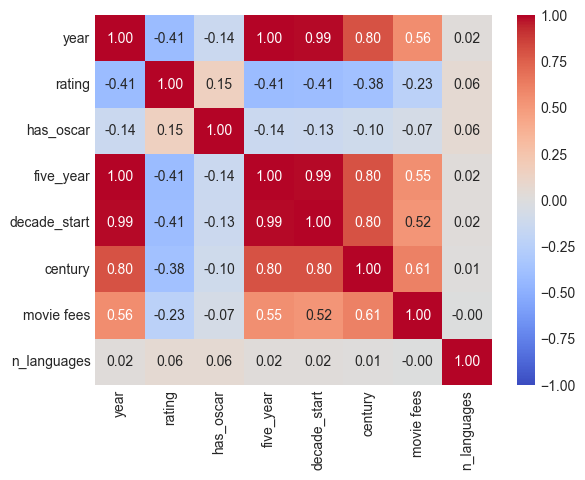

In [215]:
sns.heatmap(
    data=lost_film.corr(numeric_only=True),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
);

Отрицательный коэффициент -0.41 показывает отрицательную умеренную корреляцию между рейтингом и временными признаками (год, пятилетие, век). Это значит, что чем более совсременный фильм, тем больше у него шансов получить низкую оценку. Ниже рассмотрим эту гипотезу подробнее. Остальные показатели демонстрируют слишком незначительную корреляцию. has_oscar и n_languages не показывают корреляцию с какими-либо другими признаками. Следовательно, они малозначимы для дальнейшего анализа.
movie_fees демонстрирует умеренную положительную корреляцию с временными признаками, но этот признак был создан для демонстрации наших способностей, так как у нас не хватало количественных признаков :)

In [216]:
lost_film.corr(numeric_only=True, method='spearman')['n_languages'].sort_values()

movie fees     -0.016633
decade_start   -0.013769
year           -0.011011
five_year      -0.010439
century        -0.008917
has_oscar       0.082595
rating          0.107478
n_languages     1.000000
Name: n_languages, dtype: float64

Популярность жанров по 5-ти летиям

In [217]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [218]:
if 'genre' in full_film_merged.columns:
    full_film_merged['genres_split'] = full_film_merged['genre'].str.split(',')

    genre_year_pairs = []
    for idx, row in full_film_merged.iterrows():
        if isinstance(row['genres_split'], list):
            for genre in row['genres_split']:
                genre_clean = genre.strip()
                genre_year_pairs.append((row['five_year'], genre_clean))

    if genre_year_pairs:
        genre_df = pd.DataFrame(genre_year_pairs, columns=['five_year', 'genre'])
        genre_counts = genre_df.groupby(['five_year', 'genre']).size().reset_index(name='count')
    else:
        print("Нет данных о жанрах")
        genre_counts = None
else:
    print("Столбец 'genre' не найден")
    genre_counts = None

In [219]:
#находим самый популярный жанр для каждого пятилетия
top_genres = genre_counts.loc[genre_counts.groupby('five_year')['count'].idxmax()]
top_genres = top_genres.sort_values('five_year')

#также получаем топ-3 жанра для каждого пятилетия для более детальной визуализации
top3_genres_by_year = {}
for year in genre_df['five_year'].unique():
    year_data = genre_df[genre_df['five_year'] == year]
    genre_counts_year = Counter(year_data['genre'])
    top3 = dict(genre_counts_year.most_common(5))
    top3_genres_by_year[year] = top3

#создаем DataFrame для тепловой карты
heatmap_data = genre_counts.pivot(index='genre', columns='five_year', values='count').fillna(0)

#выбираем топ-5 жанров за все время
top5_overall = genre_df['genre'].value_counts().head(5).index.tolist()

#подготовка данных для линейного графика
line_data = genre_counts[genre_counts['genre'].isin(top5_overall)].pivot(
    index='five_year', columns='genre', values='count'
).fillna(0)

<Axes: xlabel='genre', ylabel='count'>

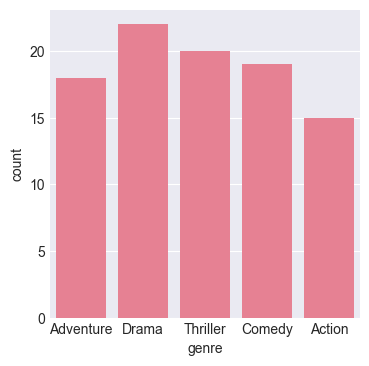

In [220]:
# Визуализация 1: Линейный график топ-5 жанров
plt.figure(figsize=(4, 4))
sns.countplot(x=genre_counts[genre_counts['genre'].isin(top5_overall)].genre)

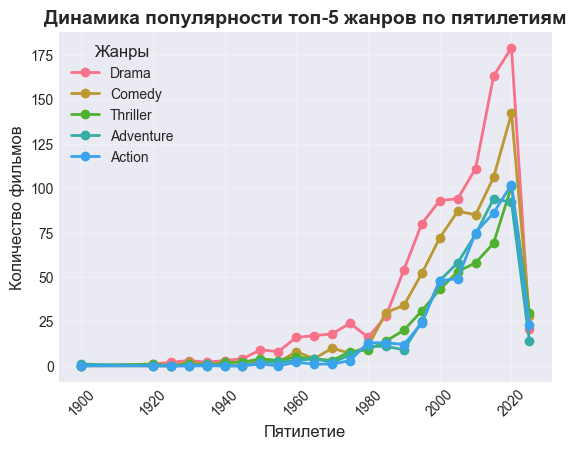

In [221]:
# График 1: Линейный график популярности топ-5 жанров
plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
for genre in top5_overall:
    if genre in line_data.columns:
        plt.plot(line_data.index, line_data[genre], marker='o', linewidth=2, markersize=6, label=genre)

plt.title('Динамика популярности топ-5 жанров по пятилетиям', fontsize=14, fontweight='bold')
plt.xlabel('Пятилетие', fontsize=12)
plt.ylabel('Количество фильмов', fontsize=12)
plt.legend(title='Жанры', title_fontsize=12, fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45);

In [222]:
#анализируем рост/падение популярности жанров
n = 4
for genre in top5_overall:
    if genre not in line_data.columns:
        continue

    series = line_data[genre].dropna()

    if len(series) < 2:
        continue

    recent = series.tail(n)

    start_value = recent.iloc[0]
    end_value = recent.iloc[-1]

    if start_value == 0:
        continue

    change_pct = (end_value - start_value) / start_value * 100

    if change_pct > 0:
        trend = "hост"
    elif change_pct < 0:
        trend = "спад"
    else:
        trend = "без изменений"

    print(
        f"{genre}: {trend} "
        f"({start_value:.2f} → {end_value:.2f}, "
        f"{abs(change_pct):.1f}%)"
    )

Drama: спад (111.00 → 21.00, 81.1%)
Comedy: спад (85.00 → 28.00, 67.1%)
Thriller: спад (58.00 → 30.00, 48.3%)
Adventure: спад (74.00 → 14.00, 81.1%)
Action: спад (75.00 → 23.00, 69.3%)


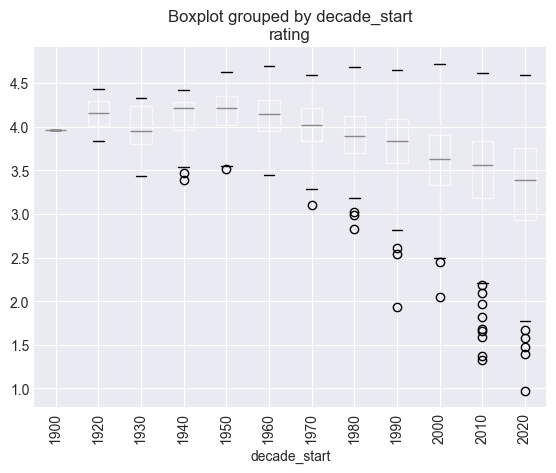

In [223]:
full_film_merged.boxplot(column="rating", by="decade_start", rot=90);

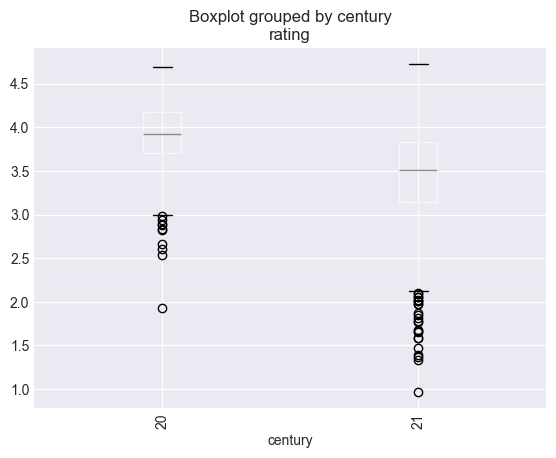

In [224]:
full_film_merged.boxplot(column="rating", by="century", rot=90);

Чем ближе к современности, тем больше выбросов и больше разброс в оценках и ниже медианная оценка, с учётом отсутствия нормализации.

Фильмы XX века в среднем имеют более высокие рейтинги, чем фильмы XXI века, а распределение оценок в XX веке более компактное.

В XXI веке наблюдается больший разброс рейтингов и большее количество низко оценённых фильмов, что может быть связано с ростом объёма выпускаемых фильмов и большей неоднородностью контента.

Наличие фильмов с очень высокими рейтингами в обоих веках говорит о том, что век выпуска сам по себе не является определяющим фактором качества или популярности фильма.


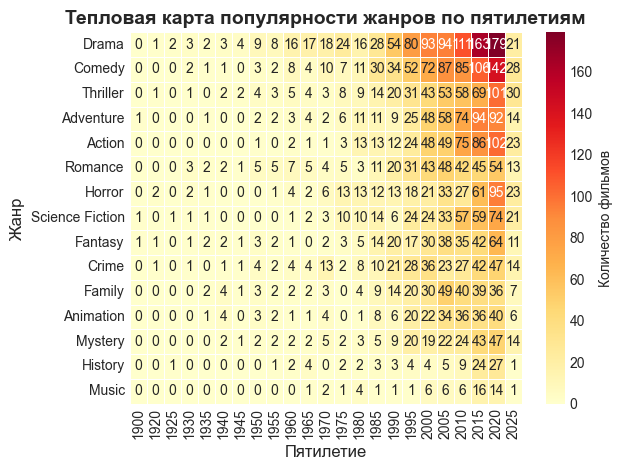

In [225]:
# Тепловая карта
top_genres_alltime = genre_df['genre'].value_counts().head(15).index
heatmap_filtered = heatmap_data.loc[top_genres_alltime]

sns.heatmap(heatmap_filtered, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Количество фильмов'})
plt.title('Тепловая карта популярности жанров по пятилетиям', fontsize=14, fontweight='bold')
plt.xlabel('Пятилетие', fontsize=12)
plt.ylabel('Жанр', fontsize=12)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [226]:
filtered_df = full_film_merged[(full_film_merged['decade_start'] >= 1980) & (full_film_merged['decade_start'] <= 2020)] # убираем декады ранее 1980 и позже 2020

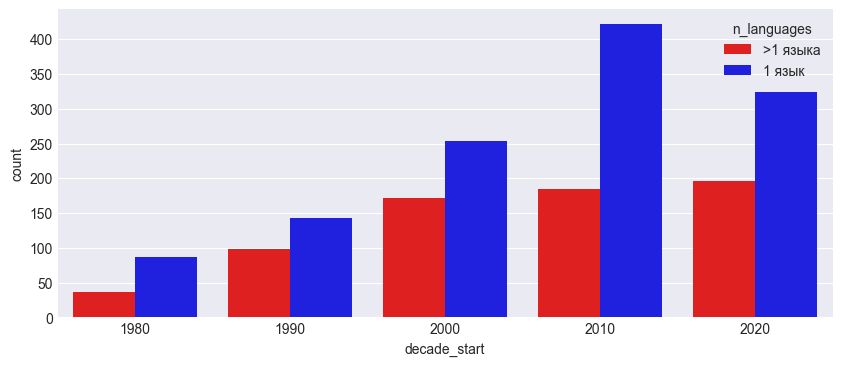

In [227]:
df_filtered = full_film_merged[(full_film_merged['decade'].str.split('–').str[0].astype(int) >= 1980) & (full_film_merged['decade'].str.split('–').str[0].astype(int) <= 2020)]
plt.figure(figsize=(10, 4))
sns.countplot(x=df_filtered.decade_start,
    hue=df_filtered['n_languages'].apply(lambda x: '1 язык' if x == 1 else '>1 языка'),
    palette=['red', 'blue']);

Абсолютное большинство фильмов снято на одном языке, особенно это заметно  в 2000-2020 годах, где разрыв по количеству фильмов на разных языков только увеличивается. Несмотря на то, что международных фильмов становится больше, всё-таки преобладают фильмы на одном языке

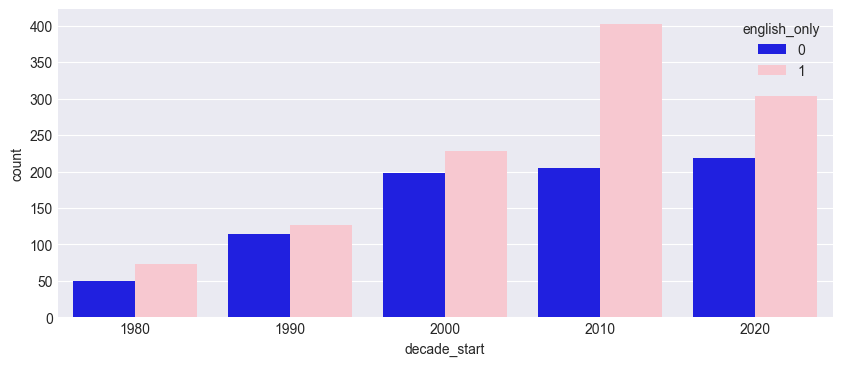

In [237]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df_filtered,
    x='decade_start',
    hue='english_only',
    palette=['blue', 'pink']);

- english_only = 1 — фильмы исключительно на английском языке
- english_only = 0 — фильмы с несколькими языками или не только на английском
По графику видно, что растёт количество выпускаемых фильмов на нескольких языках одновременно. Однако, для всех демятилетий доминирование английского языка сохраняется. Для нашего режисссёра это означает, что можно снимать фильм только на английском языке.

In [229]:
print("="*60)
print("АНАЛИЗ МОДЫ НА ЖАНРЫ ПО ПЯТИЛЕТИЯМ")
print("="*60)

print("\nЭВОЛЮЦИЯ САМЫХ ПОПУЛЯРНЫХ ЖАНРОВ:")
for idx, row in top_genres.iterrows():
    print(f"{int(row['five_year'])}-{int(row['five_year']+4)}: {row['genre']} ({row['count']} фильмов)")

АНАЛИЗ МОДЫ НА ЖАНРЫ ПО ПЯТИЛЕТИЯМ

ЭВОЛЮЦИЯ САМЫХ ПОПУЛЯРНЫХ ЖАНРОВ:
1900-1904: Adventure (1 фильмов)
1920-1924: Horror (2 фильмов)
1925-1929: Drama (2 фильмов)
1930-1934: Drama (3 фильмов)
1935-1939: Drama (2 фильмов)
1940-1944: Animation (4 фильмов)
1945-1949: Drama (4 фильмов)
1950-1954: Drama (9 фильмов)
1955-1959: Drama (8 фильмов)
1960-1964: Drama (16 фильмов)
1965-1969: Drama (17 фильмов)
1970-1974: Drama (18 фильмов)
1975-1979: Drama (24 фильмов)
1980-1984: Drama (16 фильмов)
1985-1989: Comedy (30 фильмов)
1990-1994: Drama (54 фильмов)
1995-1999: Drama (80 фильмов)
2000-2004: Drama (93 фильмов)
2005-2009: Drama (94 фильмов)
2010-2014: Drama (111 фильмов)
2015-2019: Drama (163 фильмов)
2020-2024: Drama (179 фильмов)
2025-2029: Thriller (30 фильмов)


Вывод: Самый популярный жанр на века - драма. Может, что-то изменится в следующем пятилетии, но говорить об этом рано. Заметим, что в последние 5-10 лет всё больше выпускают фильмов с жанрами ужасы, приключения, комедия и экшн, а в последние 5 лет - триллер. Отметим, что на графике общее кол-во популярных фильмов по жанру в декаде, т.е. не учитывается, что фильмов попросту снимают всё больше.

Облако слов для актеров:

In [232]:
all_actors = []
if 'actors' in full_film_merged.columns:
    for actors_list in full_film_merged['actors'].dropna():
        if isinstance(actors_list, list):
            all_actors.extend(actors_list)
        elif isinstance(actors_list, str):
            actors = [a.strip() for a in actors_list.split(',') if a.strip()]
            all_actors.extend(actors)
if len(all_actors) > 0:
    actor_counts = Counter(all_actors)

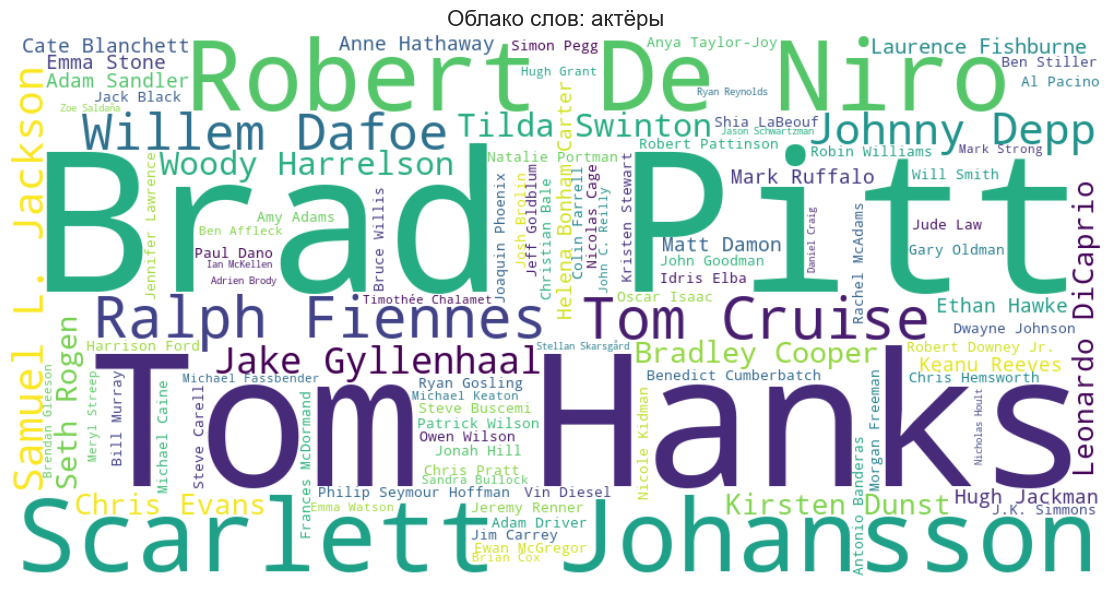

In [233]:
wordcloud = WordCloud(
width=1000,
height=500,
background_color='white',
max_words=100
).generate_from_frequencies(actor_counts)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов: актёры', fontsize=16)
plt.tight_layout()
plt.show()

Из актеров чаще всего в популярных фильмах снимаются Бред Питт, Том Хэнкс, Скарлетт Йоханссон, Роберт де Ниро

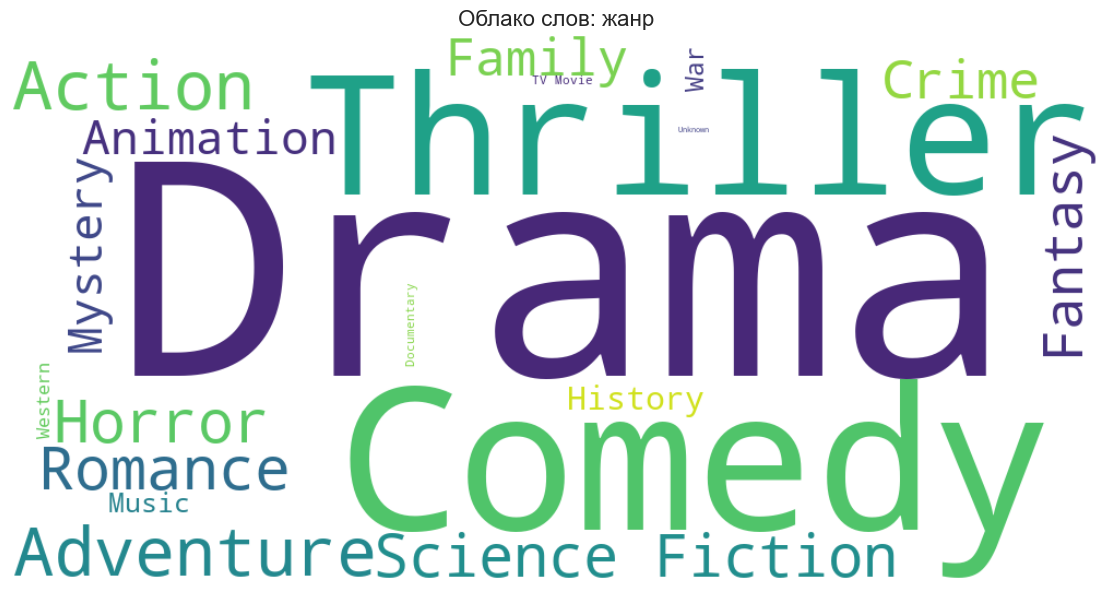

In [238]:
all_genres = genre_df['genre'].tolist()
genre_counts = Counter(all_genres)

wordcloud = WordCloud(
width=1000,
height=500,
background_color='white',
max_words=100
).generate_from_frequencies(genre_counts)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов: жанр', fontsize=16)
plt.tight_layout()
plt.show()

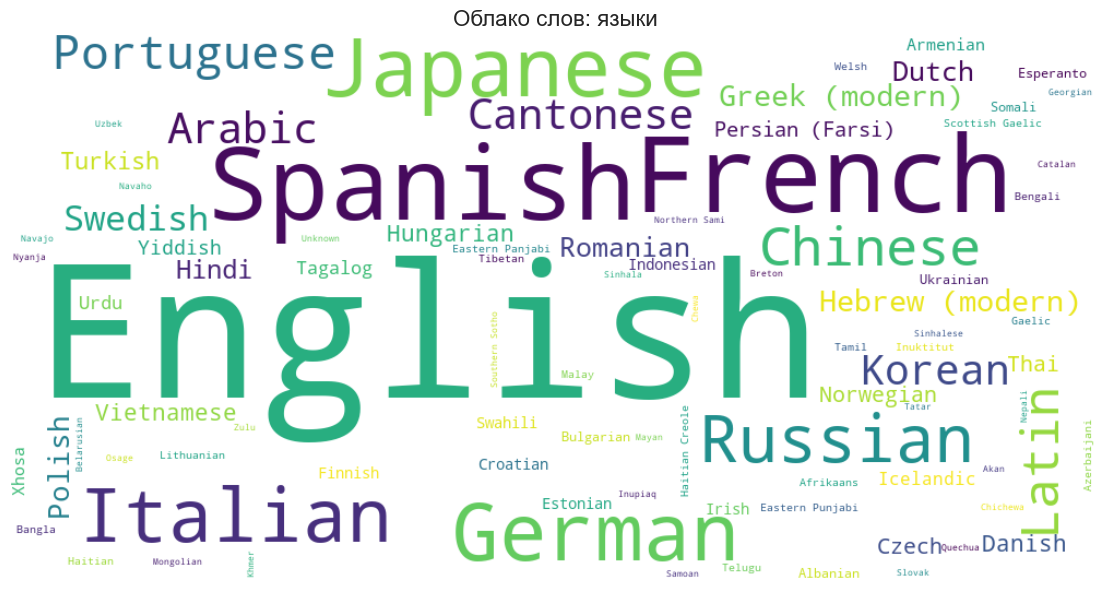

In [242]:
full_film_merged['language_list'] = full_film_merged['language_set'].apply(
    lambda x: list(x) if isinstance(x, set) else ([] if pd.isna(x) else [x]))

all_languages = []

for language_list in full_film_merged['language_list'].dropna():
    if isinstance(language_list, list):
        all_languages.extend(language_list)

languages_counts = Counter(all_languages)
if 'No spoken language' in languages_counts:
    del languages_counts['No spoken language']
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate_from_frequencies(languages_counts)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов: языки', fontsize=16)
plt.tight_layout()
plt.show()

Корреляция бюджета картины с рейтингом и награды Оскар

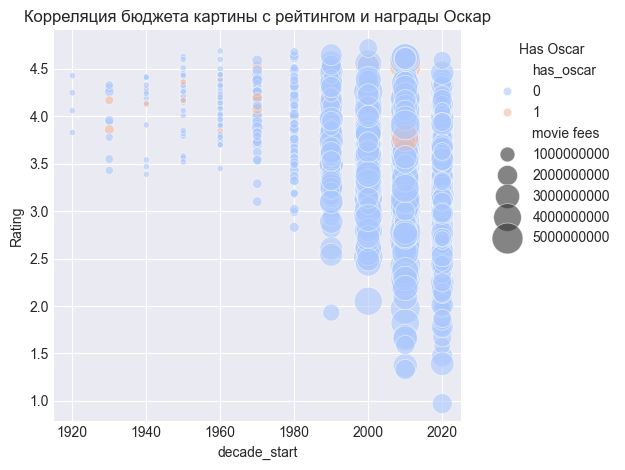

In [239]:
sns.scatterplot(data=full_film_merged,
                x='decade_start',
                y='rating',
                hue='has_oscar',
                size='movie fees',  # или другая колонка для box_office
                sizes=(20, 500),
                alpha=0.6,
               palette='coolwarm')
#plt.xscale('log')
plt.title('Корреляция бюджета картины с рейтингом и награды Оскар')
plt.xlabel('decade_start')
plt.ylabel('Rating')
plt.legend(title='Has Oscar', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Кассовые сборы со временем увеличиваются. Фильмы с Оскаром имеют больший рейтинг, занимают верхнюю часть графика. Следует отметить, что размер кассовых сборов не зависит от рейтинга. Это открывает нам возможность подумать о дополнительных параметрах для проведения более глубокого анализа, таких как бюджет фильма.

In [240]:
def compare_rating_by_flag(df, col):
    out = (
        df.groupby(col)["rating"]
        .agg(count="count", mean="mean", median="median", std="std")
        .reset_index()
        .sort_values(col)
    )
    out["mean"] = out["mean"].round(3)
    out["median"] = out["median"].round(3)
    out["std"] = out["std"].round(3)
    return out

for col in ["has_oscar", "hollywood", "english_only", "international"]:
    display(compare_rating_by_flag(full_film_merged, col))

,has_oscar,count,mean,median,std
0,0,2045,3.569,3.630,0.536
1,1,56,4.083,4.105,0.242


,hollywood,count,mean,median,std
0,0,412,3.862,3.935,0.481
1,1,1689,3.514,3.580,0.528


,english_only,count,mean,median,std
0,0,892,3.726,3.80,0.512
1,1,1209,3.477,3.54,0.530


,international,count,mean,median,std
0,1,2101,3.582,3.66,0.537


- фильмы с Оскаром имеют выше рейтинг, чем без него; у них более маленькое стандарное отклонение, они более сосредоточены в зоне повышенного рейтинга
- если фильм снят в Америке, то рейтинг ниже, чем если бы фильм был снят не в Америке (но везде большое стандартное отклонение)
- фильмы только на английском в среднем имеют более низкую оценку, чем фильмы на нескольких языках (но везде большое стандартное отклонение)
- по флагу international различия не существенны

In [241]:
full_film_merged["hollywood"] = full_film_merged["country"].astype(str).str.contains("USA", na=False).astype(int)
# Hollywood (USA production) vs rating
compare_rating_by_flag(full_film_merged, "hollywood")

,hollywood,count,mean,median,std
0,0,412,3.862,3.935,0.481
1,1,1689,3.514,3.580,0.528


Наличие награды «Оскар» связано с несколько более высокими рейтингами, однако данная связь не является определяющей.

**Результаты по этапу:**

- рейтинг фильмов слабо коррелирует с большинством количественных признаков, что указывает на многомерную и сложную природу популярности фильмов;
- распределение рейтингов по десятилетиям остаётся относительно стабильным, несмотря на рост количества выпускаемых фильмов;
- жанровые предпочтения меняются со временем, однако драма остаётся наиболее устойчивым жанром;
- оскароносные фильмы в среднем имеют более высокие рейтинги, но среди высоко оценённых фильмов присутствует значительное количество картин без наград;
- визуализация связей между рейтингом, временем выпуска и кассовыми сборами подчёркивает отсутствие простой линейной зависимости.

Отметим, что полученные результаты носят описательный характер и не позволяют делать выводы о причинно-следственных связях. Однако они позволяют определить направления для дальнейшего анализа.


# Выводы

**Главные выводы:**

1. Жанровая структура популярных фильмов стабильна во времени: **драма** встречается чаще других жанров.
2. Наличие премии **«Оскар»** связано с более высоким средним рейтингом, однако среди лидеров рейтинга много фильмов без наград.
3. Эффект языковых и производственных признаков на рейтинги фильмов невелик, а значит, следует искать секрет гарантированной популярости в других признаках.
4. Так как корреляции между рейтингом и количественными признаками в очень слабые, мы не можем делать какие-либо однозначные выводы об их влиянии; с чем связаны те или иные оценки для нас остается загадкой, требующей допролнительных данных, новый признаков и углубленного анализа.

Ограничения: выборка состоит из популярных фильмов Letterboxd, поэтому выводы не обязательно распространяются на всё кино в целом. Кроме того, признак "бюджет" был создан автоматически для иллюстрации, не для анализа; в идеале добавить реальные цифры. Мы не умеем по курсу искать каузацию, так что здесь представлена исключительно описательныя статистика и поиск корреляций.
